<a href="https://colab.research.google.com/github/ngocthi12123-cloud/BTVN2/blob/main/btvn2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Giá đi xe: 43 nghìn đồng 
Điểm thưởng: 6 điểm


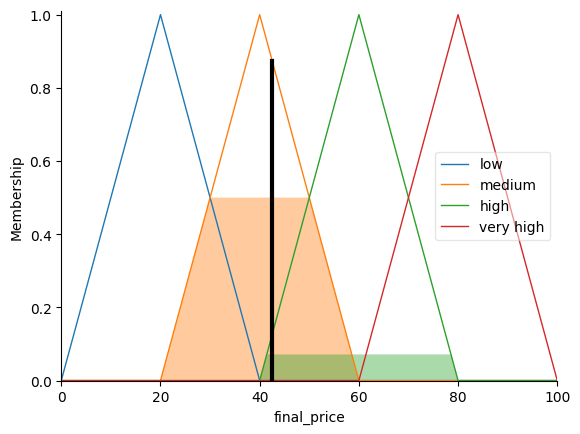

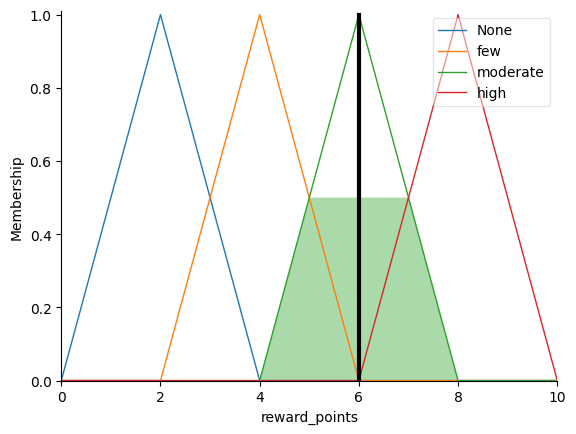

In [125]:
#2.11
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
ride_distance = ctrl.Antecedent(np.arange(0, 51, 1), 'ride_distance')
traffic_condition = ctrl.Antecedent(np.arange(0, 11, 1), 'traffic_condition')
demand_level = ctrl.Antecedent(np.arange(0, 11, 1), 'demand_level')
weather_condition = ctrl.Antecedent(np.arange(0, 11, 1), 'weather_condition')
customer_rating = ctrl.Antecedent(np.arange(1, 5.1,0.1), 'customer_rating')
ride_punctuality = ctrl.Antecedent(np.arange(0, 11, 1), 'ride_punctuality')
final_price = ctrl.Consequent(np.arange(0, 101, 1), 'final_price')
reward_points = ctrl.Consequent(np.arange(0, 11, 1), 'reward_points')
final_price['low']=fuzz.trimf(final_price.universe,[0,20,40])
final_price['medium']=fuzz.trimf(final_price.universe,[20,40,60])
final_price['high']=fuzz.trimf(final_price.universe,[40,60,80])
final_price['very high']=fuzz.trimf(final_price.universe,[60,80,100])
reward_points['None']=fuzz.trimf(reward_points.universe,[0,2,4])
reward_points['few']=fuzz.trimf(reward_points.universe,[2,4,6])
reward_points['moderate']=fuzz.trimf(reward_points.universe,[4,6,8])
reward_points['high']=fuzz.trimf(reward_points.universe,[6,8,10])
ride_distance['short']=fuzz.trimf(ride_distance.universe,[0,0,3])
ride_distance['medium']=fuzz.trimf(ride_distance.universe,[2,8,15])
ride_distance['long']=fuzz.trimf(ride_distance.universe,[6,20,50])
ride_distance['very long']=fuzz.trimf(ride_distance.universe,[15,50,50])
traffic_condition['low']=fuzz.trimf(traffic_condition.universe,[0,0,3])
traffic_condition['medium']=fuzz.trimf(traffic_condition.universe,[2,5,7])
traffic_condition['high']=fuzz.trimf(traffic_condition.universe,[6,10,10])
demand_level['low']=fuzz.trimf(demand_level.universe,[0,0,3])
demand_level['medium']=fuzz.trimf(demand_level.universe,[2,5,7])
demand_level['high']=fuzz.trimf(demand_level.universe,[6,10,10])
weather_condition['good']=fuzz.trimf(weather_condition.universe,[0,0,5])
weather_condition['moderate']=fuzz.trimf(weather_condition.universe,[0,5,10])
weather_condition['bad']=fuzz.trimf(weather_condition.universe,[5,10,10])
customer_rating['poor']=fuzz.trimf(customer_rating.universe,[1,1,2.5])
customer_rating['average']=fuzz.trimf(customer_rating.universe,[2,3,4])
customer_rating['good']=fuzz.trimf(customer_rating.universe,[3.5,4.5,5])
ride_punctuality['late']=fuzz.trimf(ride_punctuality.universe,[0,3,5])
ride_punctuality['on time']=fuzz.trimf(ride_punctuality.universe,[4,6,8])
ride_punctuality['early']=fuzz.trimf(ride_punctuality.universe,[7,10,10])
rule1=ctrl.Rule(ride_distance['short']&traffic_condition['low']&demand_level['low'],final_price['low'])
rule2=ctrl.Rule(ride_distance['short']&traffic_condition['medium']&demand_level['high'],final_price['medium'])
rule3=ctrl.Rule(ride_distance['medium']&traffic_condition['high']&demand_level['high'],final_price['high'])
rule4=ctrl.Rule(ride_distance['long']&traffic_condition['medium']&weather_condition['good'],final_price['high'])
rule5=ctrl.Rule(ride_distance['long']&traffic_condition['high']&weather_condition['bad'],final_price['very high'])
rule6 = ctrl.Rule(ride_distance['long'] & traffic_condition['high'] & demand_level['high'], final_price['very high'])
rule7 = ctrl.Rule(ride_distance['medium'] & traffic_condition['low'] & demand_level['low'], final_price['medium'])
rule8 = ctrl.Rule(ride_distance['short'] & traffic_condition['high'] & weather_condition['bad'], final_price['high'])
rule9 = ctrl.Rule(ride_distance['long'] & weather_condition['bad'], final_price['very high'])
rule10 = ctrl.Rule(ride_distance['medium'] & traffic_condition['medium'] & weather_condition['moderate'], final_price['medium'])
rule11 = ctrl.Rule(customer_rating['good'] & ride_punctuality['early'], reward_points['high'])
rule12 = ctrl.Rule(customer_rating['average'] & ride_punctuality['on time'], reward_points['moderate'])
rule13 = ctrl.Rule(customer_rating['poor'] & ride_punctuality['late'], reward_points['None'])
rule14 = ctrl.Rule(ride_distance['long'] & traffic_condition['high'] & ride_punctuality['on time'], reward_points['high'])
rule15 = ctrl.Rule(ride_distance['medium'] & traffic_condition['medium'] & customer_rating['good'], reward_points['moderate'])
rule16 = ctrl.Rule(customer_rating['poor'] & ride_punctuality['late'], reward_points['None'])
rule17 = ctrl.Rule(ride_distance['long'] & weather_condition['bad'] & customer_rating['good'], reward_points['high'])
rule18 = ctrl.Rule(ride_distance['short'] & customer_rating['average'] & ride_punctuality['on time'], reward_points['few'])
rule19 = ctrl.Rule(ride_distance['long'] & traffic_condition['high'] & ride_punctuality['late'], reward_points['few'])
rule20 = ctrl.Rule(ride_distance['medium'] & weather_condition['moderate'] & customer_rating['good'], reward_points['moderate'])
rules=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,rule13,rule14,rule15,rule16,rule17,rule18,rule19,rule20])
rules_sim=ctrl.ControlSystemSimulation(rules)
rules_sim.input['ride_distance']=7
rules_sim.input['traffic_condition']=6
rules_sim.input['demand_level']=7
rules_sim.input['weather_condition']=4
rules_sim.input['customer_rating']=4
rules_sim.input['ride_punctuality']=7
rules_sim.compute()
print(f"Giá đi xe: {round(rules_sim.output['final_price'])} nghìn đồng ")
print(f"Điểm thưởng: {round(rules_sim.output['reward_points'])} điểm")
final_price.view(sim=rules_sim)
reward_points.view(sim=rules_sim)

In [2]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 13.2 MB/s eta 0:00:00


30.999999999999996


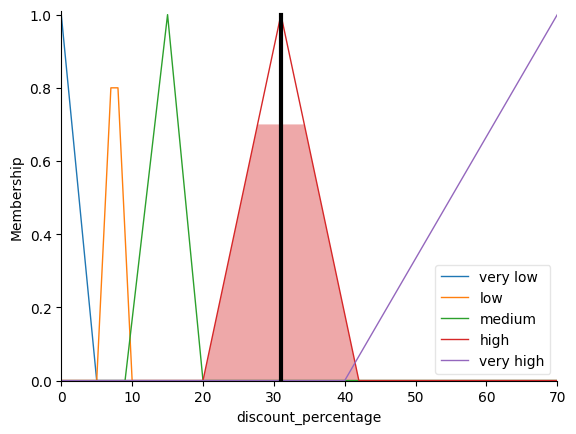

In [135]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
store_rating=ctrl.Antecedent(np.arange(1,5.1,0.1),'store_rating')
sales_voliume=ctrl.Antecedent(np.arange(0,101,1),'sales_voliume')
profit_margin=ctrl.Antecedent(np.arange(0,101,1),'profit_margin')
seasonal_event=ctrl.Antecedent(np.arange(0,11,1),'seasonal_event')
competition_discounts=ctrl.Antecedent(np.arange(0,101,1),'competition_discounts')
discount_percentage=ctrl.Consequent(np.arange(0,71,1),'discount_percentage')
discount_percentage['very low']=fuzz.trimf(discount_percentage.universe,[0,0,5])
discount_percentage['low']=fuzz.trimf(discount_percentage.universe,[5,7.5,10])
discount_percentage['medium']=fuzz.trimf(discount_percentage.universe,[9,15,20])
discount_percentage['high']=fuzz.trimf(discount_percentage.universe,[20,31,42])
discount_percentage['very high']=fuzz.trimf(discount_percentage.universe,[40,70,70])
store_rating['low']=fuzz.trimf(store_rating.universe,[0,3.5,4])
store_rating['medium']=fuzz.trimf(store_rating.universe,[3.9,4.3,4.5])
store_rating['high']=fuzz.trimf(store_rating.universe,[4.4,5,5])
sales_voliume['low']=fuzz.trimf(sales_voliume.universe,[0,0,50])
sales_voliume['medium']=fuzz.trimf(sales_voliume.universe,[25,50,75])
sales_voliume['high']=fuzz.trimf(sales_voliume.universe,[50,100,100])
profit_margin['low']=fuzz.trimf(profit_margin.universe,[0,0,50])
profit_margin['medium']=fuzz.trimf(profit_margin.universe,[25,50,75])
profit_margin['high']=fuzz.trimf(profit_margin.universe,[50,100,100])
seasonal_event['none']=fuzz.trimf(seasonal_event.universe,[0,0,5])
seasonal_event['moderate']=fuzz.trimf(seasonal_event.universe,[0,5,10])
seasonal_event['high']=fuzz.trimf(seasonal_event.universe,[5,10,10])
competition_discounts['low']=fuzz.trimf(competition_discounts.universe,[0,0,50])
competition_discounts['medium']=fuzz.trimf(competition_discounts.universe,[25,50,75])
competition_discounts['high']=fuzz.trimf(competition_discounts.universe,[50,100,100])
rules=[
    ctrl.Rule(store_rating['high']&sales_voliume['high']&profit_margin['high'],discount_percentage['very low']),
    ctrl.Rule(store_rating['low']&sales_voliume['low']&profit_margin['high'],discount_percentage['high']),
    ctrl.Rule(seasonal_event['high']&competition_discounts['high'],discount_percentage['high']),
    ctrl.Rule(store_rating['medium']&sales_voliume['medium']&profit_margin['medium'],discount_percentage['medium']),
    ctrl.Rule(competition_discounts['low']&profit_margin['low']&sales_voliume['high'],discount_percentage['very low']),
    ctrl.Rule(store_rating['low']&seasonal_event['none'],discount_percentage['medium']),
    ctrl.Rule(store_rating['low']&profit_margin['low'],discount_percentage['very high'])
    ]
discount_ctrl=ctrl.ControlSystem(rules)
discount_sim=ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['store_rating']=4.3
discount_sim.input['sales_voliume']=50
discount_sim.input['profit_margin']=20
discount_sim.input['seasonal_event']=9
discount_sim.input['competition_discounts']=85
discount_sim.compute()
print(discount_sim.output['discount_percentage'])
discount_percentage.view(sim=discount_sim)

15.0


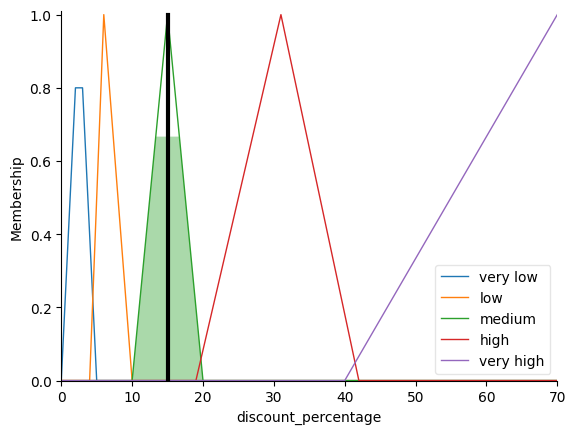

In [137]:
#2.13
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
product_demand=ctrl.Antecedent(np.arange(0,11,1),'product_demand')
competitor_pricing_presssure=ctrl.Antecedent(np.arange(0,11,1),'competitor_pricing_presssure')
store_reputation=ctrl.Antecedent(np.arange(0,5.0,0.1),'store_reputation')
profit_margin=ctrl.Antecedent(np.arange(20,101,1),'profit_margin')
seasonal_demand=ctrl.Antecedent(np.arange(0,11,1),'seasonal_demand')
discount_percentage=ctrl.Consequent(np.arange(0,71,1),'discount_percentage')
discount_percentage=ctrl.Consequent(np.arange(0,71,1),'discount_percentage')
discount_percentage['very low']=fuzz.trimf(discount_percentage.universe,[0,2.5,5])
discount_percentage['low']=fuzz.trimf(discount_percentage.universe,[4,6,10])
discount_percentage['medium']=fuzz.trimf(discount_percentage.universe,[10,15,20])
discount_percentage['high']=fuzz.trimf(discount_percentage.universe,[19,31,42])
discount_percentage['very high']=fuzz.trimf(discount_percentage.universe,[40,70,70])
product_demand['low']=fuzz.trimf(product_demand.universe,[0,0,5])
product_demand['medium']=fuzz.trimf(product_demand.universe,[0,5,10])
product_demand['high']=fuzz.trimf(product_demand.universe,[5,10,10])
competitor_pricing_presssure['low']=fuzz.trimf(competitor_pricing_presssure.universe,[0,0,5])
competitor_pricing_presssure['medium']=fuzz.trimf(competitor_pricing_presssure.universe,[0,5,10])
competitor_pricing_presssure['high']=fuzz.trimf(competitor_pricing_presssure.universe,[5,10,10])
store_reputation['low']=fuzz.trimf(store_reputation.universe,[0,0,4])
store_reputation ['medium']=fuzz.trimf(store_reputation.universe,[3.9,4.2,4.5])
store_reputation['high']=fuzz.trimf(store_reputation.universe,[4.4,5,5])
profit_margin['low']=fuzz.trimf(profit_margin.universe,[0,0,50])
profit_margin['medium']=fuzz.trimf(profit_margin.universe,[25,50,75])
profit_margin['high']=fuzz.trimf(profit_margin.universe,[50,100,100])
seasonal_demand['none']=fuzz.trimf(seasonal_demand.universe,[0,0,5])
seasonal_demand['moderate']=fuzz.trimf(seasonal_demand.universe,[5,7,10])
seasonal_demand['high']=fuzz.trimf(seasonal_demand.universe,[5,10,10])
rules=[
    ctrl.Rule(product_demand['high']&competitor_pricing_presssure['low']&profit_margin['low'],discount_percentage['very low']),
    ctrl.Rule(product_demand['low']&competitor_pricing_presssure['high']&profit_margin['high'],discount_percentage['high']),
    ctrl.Rule(store_reputation['high']&profit_margin['medium']&seasonal_demand['high'],discount_percentage['medium']),
    ctrl.Rule(competitor_pricing_presssure['high']&seasonal_demand['high']&profit_margin['high'],discount_percentage['very high']),
    ctrl.Rule(store_reputation['low']&product_demand['medium']&profit_margin['low'],discount_percentage['medium']),
    ctrl.Rule(product_demand['high']&seasonal_demand['none']&competitor_pricing_presssure['low'],discount_percentage['very low']),
    ctrl.Rule(profit_margin['high']&competitor_pricing_presssure['medium']&seasonal_demand['moderate'],discount_percentage['medium'])
    ]
discount_ctrl=ctrl.ControlSystem(rules)
discount_sim=ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['product_demand']=8
discount_sim.input['competitor_pricing_presssure']=5
discount_sim.input['store_reputation']=4.2
discount_sim.input['profit_margin']=90
discount_sim.input['seasonal_demand']=8
discount_sim.compute()
print(discount_sim.output['discount_percentage'])
discount_percentage.view(sim=discount_sim)

Số đơn kết hợp: 8
Mức độ ưu tiên giao hàng: 5


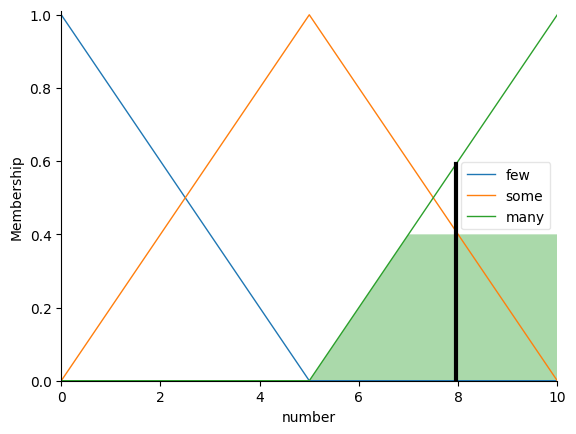

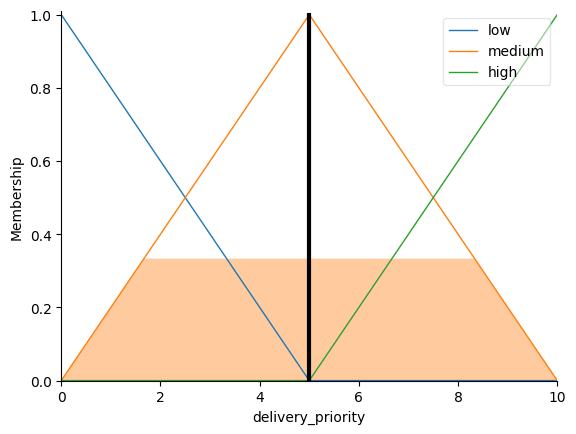

In [114]:
#2.14
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
# khai báo biến
order=ctrl.Antecedent(np.arange(0,101,1),'order')
delivery=ctrl.Antecedent(np.arange(0,11,1),'delivery')
driver=ctrl.Antecedent(np.arange(0,11,1),'driver')
traffic=ctrl.Antecedent(np.arange(0,11,1),'traffic')
profit=ctrl.Antecedent(np.arange(0,11,1),'profit')
number=ctrl.Consequent(np.arange(0,11,1),'number')
delivery_priority=ctrl.Consequent(np.arange(0,11,1),'delivery_priority')
# hàm membership
number['few']=fuzz.trimf(number.universe,[0,0,5])
number['some']=fuzz.trimf(number.universe,[0,5,10])
number['many']=fuzz.trimf(number.universe,[5,10,10])
delivery_priority['low']=fuzz.trimf(delivery_priority.universe,[0,0,5])
delivery_priority['medium']=fuzz.trimf(delivery_priority.universe,[0,5,10])
delivery_priority['high']=fuzz.trimf(delivery_priority.universe,[5,10,10])
order['low']=fuzz.trimf(order.universe,[0,0,20])
order['medium']=fuzz.trimf(order.universe,[20,50,80])
order['high']=fuzz.trimf(order.universe,[50,100,100])
delivery['low']=fuzz.trimf(delivery.universe,[0,0,5])
delivery['medium']=fuzz.trimf(delivery.universe,[0,5,10])
delivery['high']=fuzz.trimf(delivery.universe,[5,10,10])
driver['low']=fuzz.trimf(driver.universe,[0,0,5])
driver['medium']=fuzz.trimf(driver.universe,[0,5,10])
driver['high']=fuzz.trimf(driver.universe,[5,10,10])
traffic['low']=fuzz.trimf(traffic.universe,[0,0,5])
traffic['medium']=fuzz.trimf(traffic.universe,[2,5,8])
traffic['high']=fuzz.trimf(traffic.universe,[5,10,10])
profit['low']=fuzz.trimf(profit.universe,[0,0,5])
profit['medium']=fuzz.trimf(profit.universe,[0,5,10])
profit['high']=fuzz.trimf(profit.universe,[5,10,10])
# luật mờ
rules=[
    ctrl.Rule(order['high']&driver['low']&traffic['low'],number['many']),
    ctrl.Rule(order['medium']&traffic['high']&delivery['medium'],number['few']),
    ctrl.Rule(driver['high']&order['high']&profit['medium'],number['some']),
    ctrl.Rule(order['low']&delivery['high']&traffic['medium'],number['few']),
    ctrl.Rule(profit['high']&delivery['high']&traffic['high'],number['few']),
    ctrl.Rule(delivery['high']&profit['high'],delivery_priority['high']),
    ctrl.Rule(delivery['medium']&traffic['medium'],delivery_priority['medium']),
    ctrl.Rule(delivery['low']&order['high']&profit['low'],delivery_priority['low'])
    ]

discount_ctrl=ctrl.ControlSystem(rules)
discount_sim=ctrl.ControlSystemSimulation(discount_ctrl)
discount_sim.input['order']=90    # cao
discount_sim.input['delivery']=5  # trung bình
discount_sim.input['driver']=2    #thấp
discount_sim.input['traffic']=3  #trung bình
discount_sim.input['profit']=5   #trung bình
discount_sim.compute()

print(f"Số đơn kết hợp: {round(discount_sim.output['number'])}")
print(f"Mức độ ưu tiên giao hàng: {round(discount_sim.output['delivery_priority'])}")
number.view(sim=discount_sim)
delivery_priority.view(sim=discount_sim)
